In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")

import numpy as np
import pandas as pd

from src.ml.data import get_train_val_test_splits
from src.ml.evaluate import load_all_models
from src.ml.priority import score_events, PRIORITY_THRESHOLDS

bundles = load_all_models()
rf_model = bundles["rf_binary_v1"]["model"]
xgb_model = bundles["xgb_multiclass_v1"]["model"]
xgb_le = bundles["xgb_multiclass_v1"]["label_encoder"]
iforest_model = bundles["iforest_v1"]["model"]

splits = get_train_val_test_splits(sample_per_family=25_000)
X_test = splits["X_test"]
y_test_family = splits["y_test"]["attack_family_denorm"].reset_index(drop=True)
y_test_binary = splits["y_test"]["is_attack"].reset_index(drop=True)

print(f"Test set: {X_test.shape}")

21:42:53 | Loaded rf_binary_v1
21:42:53 | Loaded xgb_multiclass_v1
21:42:53 | Loaded iforest_v1
21:42:53 | Loading labeled events (≤25000/family)
21:43:55 | Loaded 118,028 labeled rows
21:43:55 | Class distribution: {'Benign': 25000, 'DoS': 25000, 'DDoS': 25000, 'Reconnaissance': 25000, 'Brute Force': 13835, 'Web Attack': 2180, 'Botnet': 1966, 'Infiltration': 36, 'Exploit': 11}
21:43:55 | Splits: train=82,619, val=11,803, test=23,606


Test set: (23606, 76)


In [2]:
scored = score_events(
    X=X_test,
    attack_families=y_test_family,
    rf_model=rf_model,
    xgb_model=xgb_model,
    xgb_le=xgb_le,
    iforest_model=iforest_model,
)
scored["true_family"] = y_test_family.values
scored["is_attack"] = y_test_binary.values

print(f"Scored {len(scored):,} events")
print(f"\nPriority score statistics:")
print(scored["priority_score"].describe().round(4))

print(f"\nPriority label distribution:")
print(scored["priority_label"].value_counts())

21:43:56 | Scoring 23,606 events through all 3 models


Scored 23,606 events

Priority score statistics:
count    23606.0000
mean         0.5563
std          0.2748
min          0.0000
25%          0.6563
50%          0.6613
75%          0.7216
max          0.8000
Name: priority_score, dtype: float64

Priority label distribution:
priority_label
high        14843
info         4836
critical     3766
low           123
medium         38
Name: count, dtype: int64


In [3]:
print("=== PRIORITY LABEL DISTRIBUTION BY TRUE CLASS ===\n")
cross = pd.crosstab(
    scored["true_family"],
    scored["priority_label"],
    margins=True,
    margins_name="Total",
)
# Reorder columns for readability
col_order = ["critical", "high", "medium", "low", "info", "Total"]
col_order = [c for c in col_order if c in cross.columns]
cross = cross[col_order]
print(cross.to_string())

=== PRIORITY LABEL DISTRIBUTION BY TRUE CLASS ===

priority_label  critical   high  medium  low  info  Total
true_family                                              
Benign                 0      9      34  122  4835   5000
Botnet                 5    388       1    0     0    394
Brute Force            0   2767       0    0     0   2767
DDoS                 807   4193       0    0     0   5000
DoS                 2943   2055       2    0     0   5000
Exploit                2      0       0    0     0      2
Infiltration           4      2       1    0     0      7
Reconnaissance         0   4999       0    0     1   5000
Web Attack             5    430       0    1     0    436
Total               3766  14843      38  123  4836  23606


In [4]:
print("=== PRIORITY-AS-ALERT METRICS ===\n")
print("If we treat 'high' or 'critical' as 'alert', here's what we catch:\n")

alert_mask = scored["priority_label"].isin(["critical", "high"])
print(f"Total alerts raised: {alert_mask.sum():,} ({alert_mask.mean()*100:.1f}% of events)")

# Per-class detection at high-or-critical level
rows = []
for cls in sorted(scored["true_family"].unique()):
    cls_mask = scored["true_family"] == cls
    n_total = cls_mask.sum()
    n_alerted = (alert_mask & cls_mask).sum()
    rows.append({
        "class": cls,
        "n_total": int(n_total),
        "n_alerted_high_or_critical": int(n_alerted),
        "alert_rate_pct": round(100 * n_alerted / n_total, 2),
    })
print(pd.DataFrame(rows).sort_values("n_total", ascending=False).to_string(index=False))

# False alarm rate on Benign
benign_alerts = ((scored["true_family"] == "Benign") & alert_mask).sum()
benign_total = (scored["true_family"] == "Benign").sum()
print(f"\nFalse alarm rate on Benign: {100 * benign_alerts / benign_total:.2f}% ({benign_alerts}/{benign_total})")

=== PRIORITY-AS-ALERT METRICS ===

If we treat 'high' or 'critical' as 'alert', here's what we catch:

Total alerts raised: 18,609 (78.8% of events)
         class  n_total  n_alerted_high_or_critical  alert_rate_pct
        Benign     5000                           9            0.18
           DoS     5000                        4998           99.96
          DDoS     5000                        5000          100.00
Reconnaissance     5000                        4999           99.98
   Brute Force     2767                        2767          100.00
    Web Attack      436                         435           99.77
        Botnet      394                         393           99.75
  Infiltration        7                           6           85.71
       Exploit        2                           2          100.00

False alarm rate on Benign: 0.18% (9/5000)


In [5]:
print("=== SAMPLE CRITICAL ALERTS (top 10 by priority score) ===\n")
critical = scored[scored["priority_label"] == "critical"].nlargest(10, "priority_score")
print(critical[[
    "true_family", "xgb_predicted_family",
    "rf_attack_proba", "xgb_attack_proba", "anomaly_score",
    "priority_score", "priority_label",
]].round(4).to_string(index=False))

=== SAMPLE CRITICAL ALERTS (top 10 by priority score) ===

 true_family xgb_predicted_family  rf_attack_proba  xgb_attack_proba  anomaly_score  priority_score priority_label
     Exploit              Exploit             0.99               1.0         1.0000          0.8000       critical
        DDoS                 DDoS             1.00               1.0         0.9720          0.7958       critical
        DDoS                 DDoS             1.00               1.0         0.9713          0.7957       critical
        DDoS                 DDoS             1.00               1.0         0.9685          0.7953       critical
        DDoS                 DDoS             1.00               1.0         0.9672          0.7951       critical
Infiltration         Infiltration             0.98               1.0         0.9667          0.7950       critical
     Exploit              Exploit             0.99               1.0         0.9650          0.7947       critical
        DDoS         

In [6]:
print("=== TINY CLASS DETECTION (Infiltration & Exploit) ===\n")

for cls in ["Infiltration", "Exploit"]:
    cls_mask = scored["true_family"] == cls
    if cls_mask.sum() == 0:
        print(f"{cls}: not in test set, skipping")
        continue

    cls_records = scored[cls_mask]
    print(f"{cls} (n={cls_mask.sum()}):")
    print(cls_records[[
        "xgb_predicted_family",
        "rf_attack_proba", "xgb_attack_proba", "anomaly_score",
        "priority_score", "priority_label",
    ]].round(4).to_string(index=False))
    print()

=== TINY CLASS DETECTION (Infiltration & Exploit) ===

Infiltration (n=7):
xgb_predicted_family  rf_attack_proba  xgb_attack_proba  anomaly_score  priority_score priority_label
        Infiltration             0.94            1.0000         0.7427          0.7614       critical
              Botnet             0.82            0.9486         0.1453          0.6384           high
        Infiltration             0.92            1.0000         0.7568          0.7635       critical
              Benign             0.67            0.0001         0.0568          0.4440         medium
        Infiltration             0.72            1.0000         0.6473          0.7471           high
        Infiltration             0.98            1.0000         0.9667          0.7950       critical
        Infiltration             0.90            1.0000         0.7663          0.7649       critical

Exploit (n=2):
xgb_predicted_family  rf_attack_proba  xgb_attack_proba  anomaly_score  priority_score priori

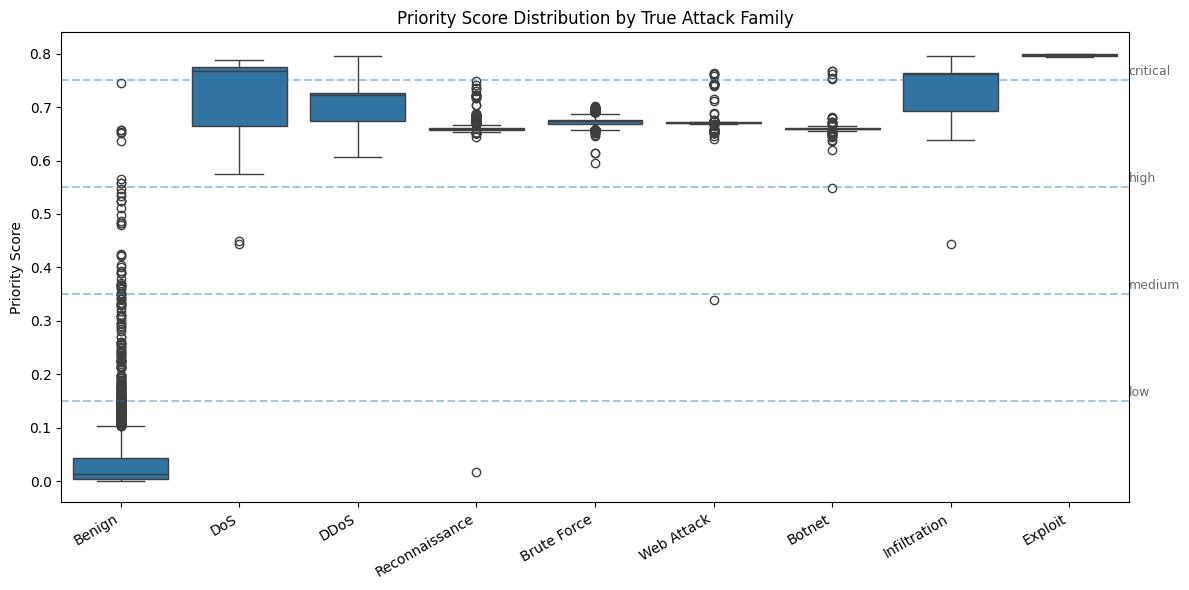

Saved: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures\ml_priority_distribution.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

order = ["Benign", "DoS", "DDoS", "Reconnaissance", "Brute Force",
         "Web Attack", "Botnet", "Infiltration", "Exploit"]
order = [c for c in order if c in scored["true_family"].unique()]

sns.boxplot(data=scored, x="true_family", y="priority_score", ax=ax, order=order)

# Annotate thresholds
for threshold, label in PRIORITY_THRESHOLDS[:-1]:
    ax.axhline(y=threshold, linestyle="--", alpha=0.4)
    ax.text(len(order) - 0.5, threshold + 0.01, label, fontsize=9, color="dimgray")

ax.set_title("Priority Score Distribution by True Attack Family")
ax.set_xlabel("")
ax.set_ylabel("Priority Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

save_path = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures") / "ml_priority_distribution.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# Testing

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ml.features import NUMERIC_FEATURES
from src.ml.evaluate import load_all_models
from src.ml.data import get_train_val_test_splits

# How the model was trained
splits = get_train_val_test_splits(sample_per_family=25_000)
X_train = splits["X_train"]
print(f"X_train column order (first 10): {list(X_train.columns[:10])}")
print(f"X_train shape: {X_train.shape}")

# What the model expects
bundles = load_all_models()
rf_model = bundles["rf_binary_v1"]["model"]
print(f"\nRF feature_names_in_ (first 10): {list(rf_model.feature_names_in_[:10])}")
print(f"RF n_features_: {rf_model.n_features_in_}")

# Compare
training_cols = list(X_train.columns)
model_cols = list(rf_model.feature_names_in_)
print(f"\nColumn order matches training: {training_cols == model_cols}")
print(f"Column set matches: {set(training_cols) == set(model_cols)}")

# Now compare against fetch_chunk
from src.ml.score import fetch_chunk
from src.warehouse import get_engine

engine = get_engine()
chunk = fetch_chunk(engine, offset=0, chunk_size=100)

# X built the same way score.py builds it
X_scoring = chunk[NUMERIC_FEATURES]
print(f"\nX_scoring column order (first 10): {list(X_scoring.columns[:10])}")
print(f"Scoring column order matches training: {list(X_scoring.columns) == training_cols}")
print(f"\nDtype comparison (first 5):")
for col in NUMERIC_FEATURES[:5]:
    print(f"  {col}: train={X_train[col].dtype}, score={X_scoring[col].dtype}")

X_train column order (first 10): ['flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'total_length_fwd', 'total_length_bwd', 'flow_bytes_per_sec', 'flow_packets_per_sec', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'down_up_ratio']
X_train shape: (82619, 76)

RF feature_names_in_ (first 10): ['flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'total_length_fwd', 'total_length_bwd', 'flow_bytes_per_sec', 'flow_packets_per_sec', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'down_up_ratio']
RF n_features_: 76

Column order matches training: True
Column set matches: True
22:08:16 | INFO    | etl          | Logging to: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\logs\etl_20260511_220816.log

X_scoring column order (first 10): ['flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'total_length_fwd', 'total_length_bwd', 'flow_bytes_per_sec', 'flow_packets_per_sec', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'down_up_ratio']
Scoring column order matches training: True

Dty